In [55]:
import os 
from dotenv import load_dotenv
import pandas as pd
import requests
from fredapi import Fred
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
import missingno as msno

In [56]:
load_dotenv(override=True)
EIA_API_KEY = os.environ['EIA_API_KEY']
FRED_API_KEY = os.environ['FRED_API_KEY']

FRED_SERIES = {
    'Inflation': 'CPIAUCSL',       
    'Interest_Rate': 'FEDFUNDS',    
    'USD_EUR': 'DEXUSEU',           
    'USD_JPY': 'DEXJPUS'            
}

In [57]:
def fetch_oil_prices(start='2019-01-01', end='2025-01-01'):
    url = (
        f'https://api.eia.gov/v2/petroleum/pri/spt/data/'
        f'?api_key={EIA_API_KEY}&frequency=monthly'
        f'&data[0]=value'
        f'&facets[product][]=EPCBRENT'
        f'&start={start}&end={end}'
        f'&sort[0][column]=period&sort[0][direction]=asc'
        f'&length=5000'
    )
    resp = requests.get(url)
    data = resp.json()['response']['data']
    df = pd.DataFrame(data)
    df['Date'] = pd.to_datetime(df['period'])
    df = df.set_index('Date')['value'].astype(float).to_frame('Crude_Oil')
    return df

In [58]:
oil_prices = fetch_oil_prices()
oil_prices.head()

,Crude_Oil
Date,
2019-01-01,59.41
2019-02-01,63.96
2019-03-01,66.14
2019-04-01,71.23
2019-05-01,71.32


In [59]:
oil_prices.tail()

,Crude_Oil
Date,
2024-08-01,80.36
2024-09-01,74.02
2024-10-01,75.63
2024-11-01,74.35
2024-12-01,73.86


In [60]:
len(oil_prices)

72

In [61]:
#--- oil prices are on monthly level

<Axes: >

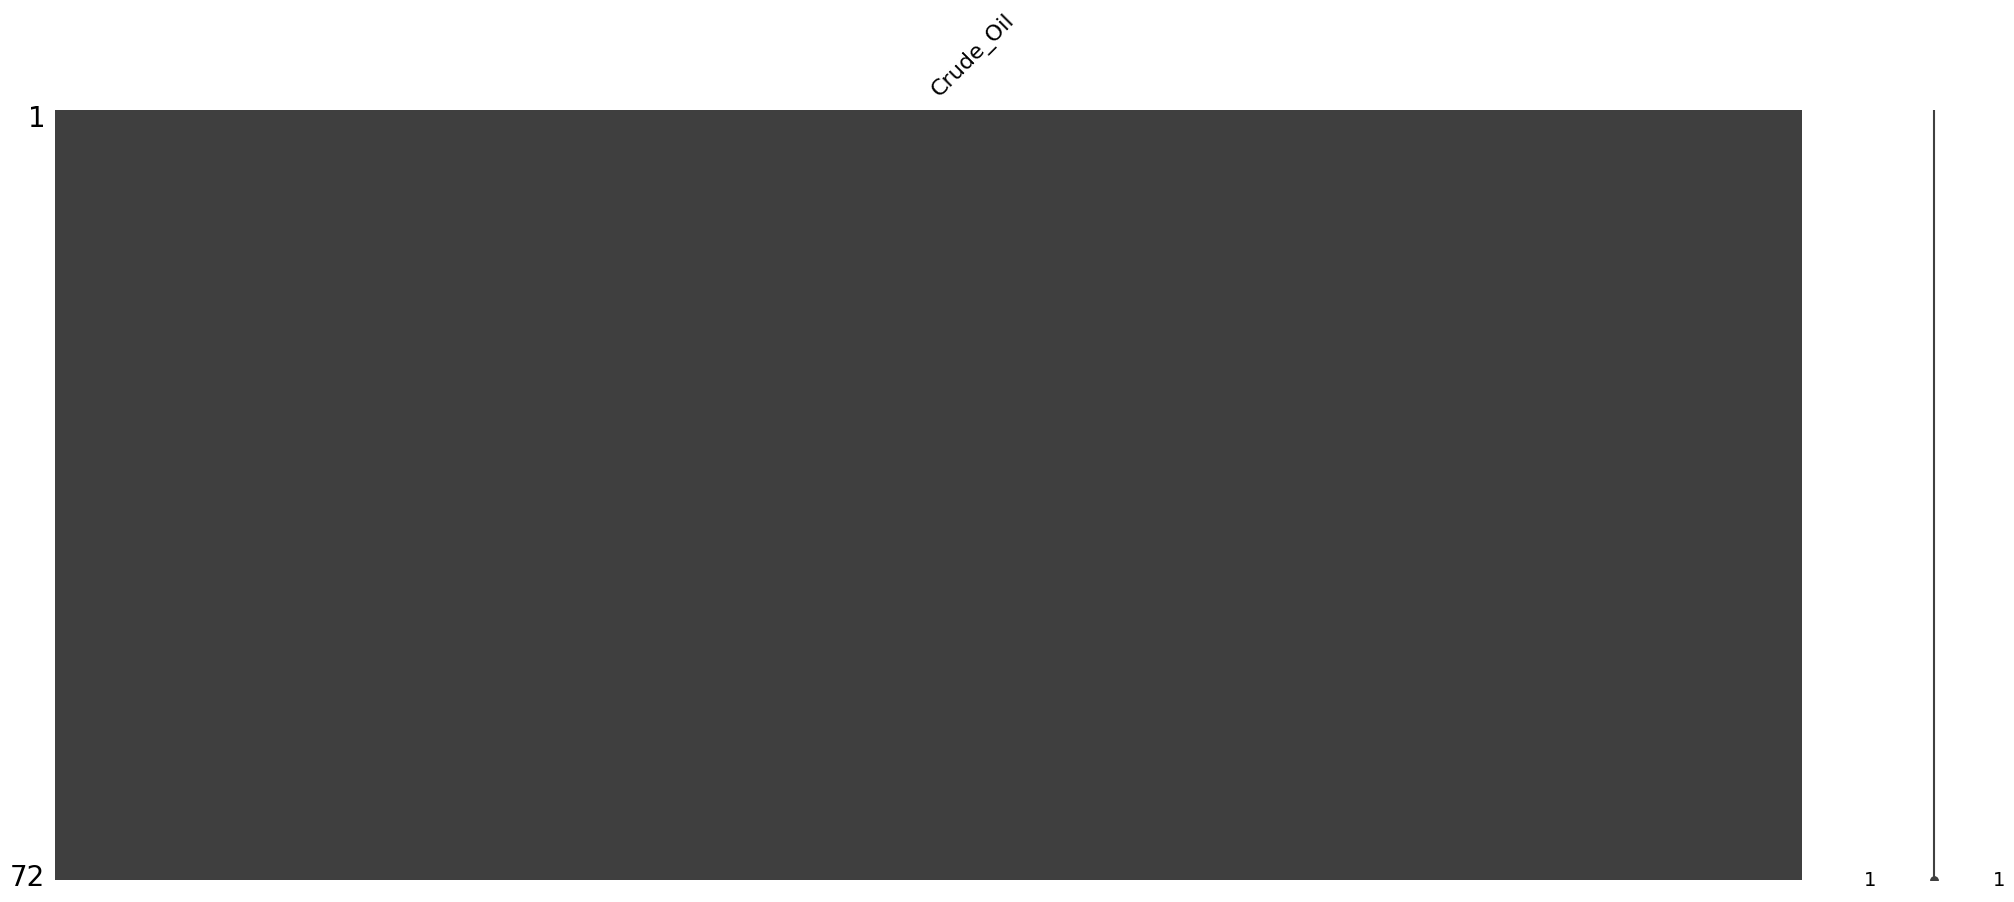

In [62]:
msno.matrix(oil_prices)

In [63]:
oil_prices = oil_prices.rename(columns={"Crude_Oil": "Crude_Oil"})
oil_prices = oil_prices.reset_index()

In [64]:
oil_prices.head()

,Date,Crude_Oil
0,2019-01-01,59.41
1,2019-02-01,63.96
2,2019-03-01,66.14
3,2019-04-01,71.23
4,2019-05-01,71.32


In [65]:
def fetch_fred_data():
    start='2019-01-01'
    end='2025-01-01'
    fred = Fred(api_key=FRED_API_KEY)
    dfs = {
        name: fred.get_series(series_id, observation_start=start, observation_end=end).rename(name)
        for name, series_id in FRED_SERIES.items()
    }
    combined = pd.concat(dfs.values(), axis=1)
    combined.index = pd.to_datetime(combined.index)
    return combined

In [66]:
fred_data = fetch_fred_data()
fred_data.head()

,Inflation,Interest_Rate,USD_EUR,USD_JPY
2019-01-01,252.561,2.4,NaN,NaN
2019-01-02,NaN,NaN,1.1357,109.22
2019-01-03,NaN,NaN,1.1399,108.07
2019-01-04,NaN,NaN,1.1410,108.29
2019-01-07,NaN,NaN,1.1468,108.62


In [67]:
fred_data = fred_data.ffill()

<Axes: >

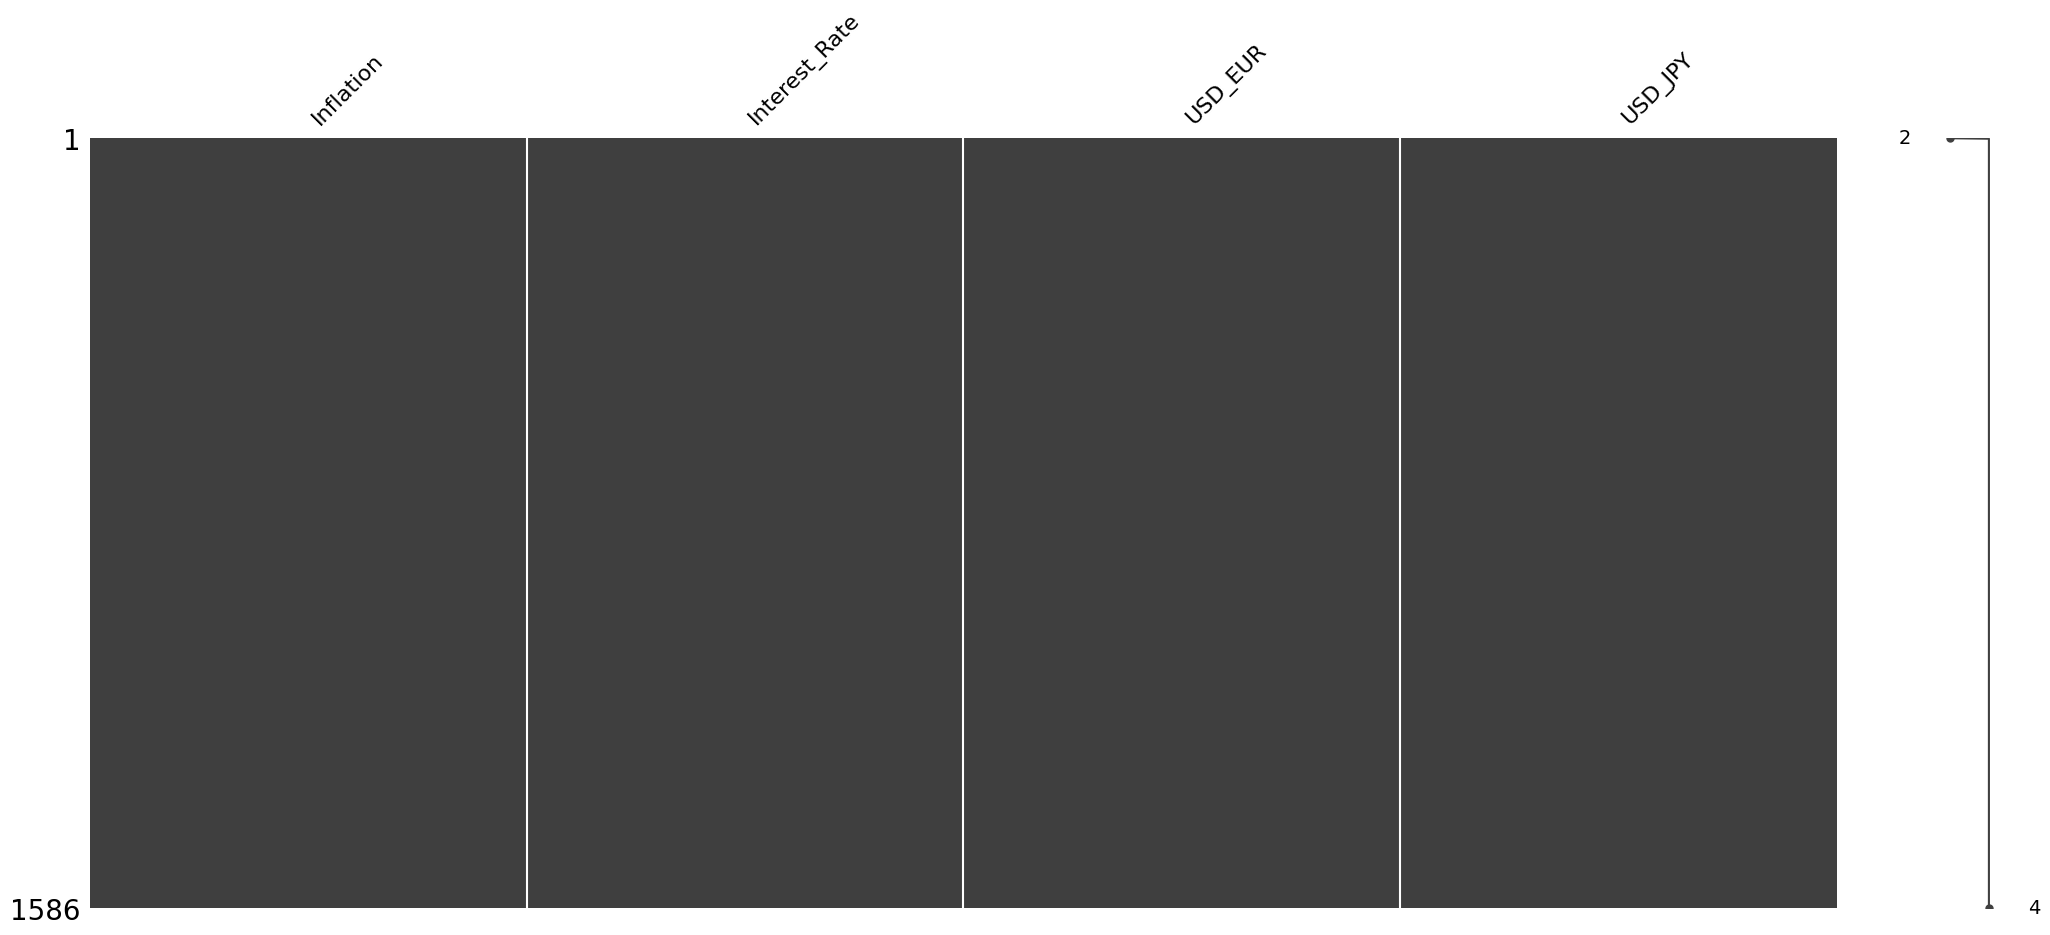

In [68]:
msno.matrix(fred_data)

In [69]:
fred_data.isnull().sum()

Inflation        0
Interest_Rate    0
USD_EUR          1
USD_JPY          1
dtype: int64

In [70]:
fred_data = fred_data.dropna()

In [71]:
fred_data = fred_data.reset_index()
fred_data.rename(columns={'index': 'Date'}, inplace=True)
fred_data['Date'] = pd.to_datetime(fred_data['Date'])
fred_data.head()

,Date,Inflation,Interest_Rate,USD_EUR,USD_JPY
0,2019-01-02,252.561,2.4,1.1357,109.22
1,2019-01-03,252.561,2.4,1.1399,108.07
2,2019-01-04,252.561,2.4,1.1410,108.29
3,2019-01-07,252.561,2.4,1.1468,108.62
4,2019-01-08,252.561,2.4,1.1444,108.57


In [72]:
gold = pd.read_csv(r'C:\Users\User\dev\training_model\dataset\dataset_v2.csv', header=1)
gold = gold.iloc[:, :2]                
gold.columns = ['Date', 'Close'] 
gold.head()

,Date,Close
0,2000-09-01,277.000000
1,2000-09-05,275.799988
2,2000-09-06,274.200012
3,2000-09-07,274.000000
4,2000-09-08,273.299988


In [73]:
gold = gold.loc[gold['Date'] >= '2019-01-01']
gold.head()

,Date,Close
4591,2019-01-02,1281.000000
4592,2019-01-03,1291.800049
4593,2019-01-04,1282.699951
4594,2019-01-07,1286.800049
4595,2019-01-08,1283.199951


In [74]:
print(gold.head())
print(oil_prices.head())
print(fred_data.head())

            Date        Close
4591  2019-01-02  1281.000000
4592  2019-01-03  1291.800049
4593  2019-01-04  1282.699951
4594  2019-01-07  1286.800049
4595  2019-01-08  1283.199951
        Date  Crude_Oil
0 2019-01-01      59.41
1 2019-02-01      63.96
2 2019-03-01      66.14
3 2019-04-01      71.23
4 2019-05-01      71.32
        Date  Inflation  Interest_Rate  USD_EUR  USD_JPY
0 2019-01-02    252.561            2.4   1.1357   109.22
1 2019-01-03    252.561            2.4   1.1399   108.07
2 2019-01-04    252.561            2.4   1.1410   108.29
3 2019-01-07    252.561            2.4   1.1468   108.62
4 2019-01-08    252.561            2.4   1.1444   108.57


In [75]:
for df in [gold, oil_prices, fred_data]:
    df['Date'] = pd.to_datetime(df['Date'])

df = gold.merge(oil_prices, on='Date', how='outer') \
               .merge(fred_data, on='Date', how='outer')

df.head()

,Date,Close,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY
0,2019-01-01,NaN,59.41,NaN,NaN,NaN,NaN
1,2019-01-02,1281.000000,NaN,252.561,2.4,1.1357,109.22
2,2019-01-03,1291.800049,NaN,252.561,2.4,1.1399,108.07
3,2019-01-04,1282.699951,NaN,252.561,2.4,1.1410,108.29
4,2019-01-07,1286.800049,NaN,252.561,2.4,1.1468,108.62


In [76]:
df = df.ffill()
df.isnull().sum()

Date             0
Close            1
Crude_Oil        0
Inflation        1
Interest_Rate    1
USD_EUR          1
USD_JPY          1
dtype: int64

In [77]:
df = df.dropna()
df.head()

,Date,Close,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY
1,2019-01-02,1281.000000,59.41,252.561,2.4,1.1357,109.22
2,2019-01-03,1291.800049,59.41,252.561,2.4,1.1399,108.07
3,2019-01-04,1282.699951,59.41,252.561,2.4,1.1410,108.29
4,2019-01-07,1286.800049,59.41,252.561,2.4,1.1468,108.62
5,2019-01-08,1283.199951,59.41,252.561,2.4,1.1444,108.57


In [79]:
df.isnull().sum()

Date             0
Close            0
Crude_Oil        0
Inflation        0
Interest_Rate    0
USD_EUR          0
USD_JPY          0
dtype: int64

In [80]:
path = 'gold_data.csv'
df.to_csv(path, index=False)